#Проєкт: Прогнозування вартості медичного страхування
Цей проєкт демонструє повний цикл ML-задачі: від збору та очищення даних до побудови регресійних моделей та оцінки їх якості.

Імпорт бібліотек та завантаження

на цьому етапі  ми завантажуємо вхідні дані з файлу insurance.csv. 
мета — провести первинний огляд структури датасету, перевірити типи даних (кількісні та категоріальні) та переконатися у відсутності пропущених значень(Missing Values).
 Ми аналізуємо такі характеристики, як вік, стать, індекс маси тіла (BMI), наявність дітей, статус куріння та регіон, щоб зрозуміти, як вони можуть впливати на цільову змінну — вартість медичного страхування ()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv('insurance.csv')

print("Перші 5 рядків даних:")
display(df.head())

Перші 5 рядків даних:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#Дані були завантажені у повному обсязі, пропуски відсутні, тому видалення рядків не знадобилос
Результат: Перевірка на пропуски показала всюди 0. дані чисті.

Статистика: Таблиця describe() показує нам, що середній вік клієнта — 39 років, а середня вартість страховки — 13 270 доларів.
Вивід останніх рядків даних
display(df.tail())

2. Попередній аналіз та очищення даних
  Перевірка на пропуски: датасет не містить порожніх значень (NaN), що свідчить про високу якість вхідних даних.


In [3]:
print("Перевірка на пропуски:")
print(df.isnull().sum())

print("\nОписова статистика:")
display(df.describe())


Описова статистика:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Перевірка на пропуски:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [ ]:
 аналіз середніх значень, мінімумів та максимумів дозволяє
зрозуміти загальний портрет клієнта (середній вік — 39 років, середні витрати — 13,270$)

Матриця кореляції (Теплова карта)
взаємозв'язки між ознаками

Матриця кореляції дозволяє кількісно оцінити зв'язок між параметрами. Ми бачимо сильну позитивну кореляцію між статусом курця та вартістю страхування

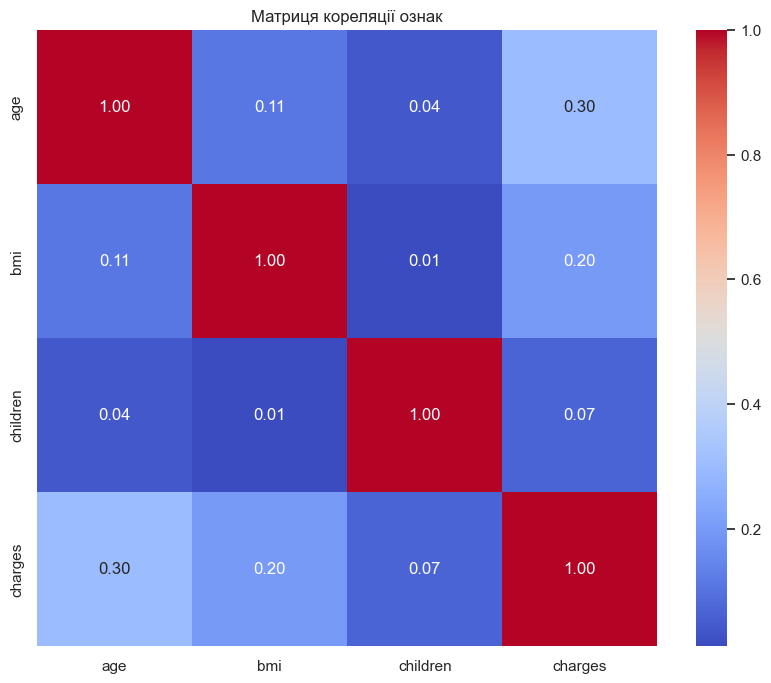

In [14]:
df_ml = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))

sns.heatmap(df_ml.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляції ознак')
plt.show()

#Підготовка до навчання
Ми використовуємо графіки, щоб побачити приховані закономірності, знайти аномалії та зрозуміти, які фактори найбільше впливають на фінальну вартість страхування.
(sns.set): Ми встановлюємо білу сітку на фоні (whitegrid)
Створення сітки (plt.subplots(1, 2
sns.histplot - показує, як часто зустрічаються ті чи інші суми страхових виплат.


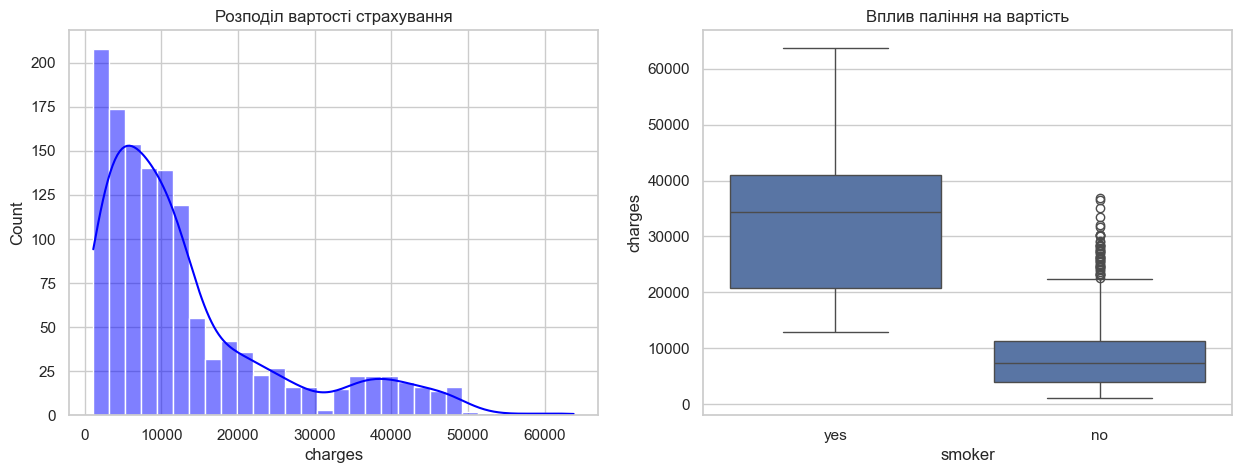

In [6]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))


sns.histplot(df['charges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Розподіл вартості страхування')


sns.boxplot(x='smoker', y='charges', data=df, ax=axes[1])
axes[1].set_title('Вплив паління на вартість')

plt.show()

#Побудова та порівняння моделей

Підготовка та кодування даних 
Для побудови моделі ми перетворюємо категоріальні змінні (sex, smoker, region) у числові формати за допомогою Binary Encoding та One-Hot Encoding. Також ми розділяємо дані на ознаки (X) та цільову змінну (y), після чого розбиваємо їх на тренувальну та тестову вибірки.

(Тут  код з .map(), pd.get_dummies() та train_test_split())

In [15]:

df_ml = df.copy()
df_ml['sex'] = df_ml['sex'].map({'female': 1, 'male': 0})
df_ml['smoker'] = df_ml['smoker'].map({'yes': 1, 'no': 0})

df_ml = pd.get_dummies(df_ml, columns=['region'])


X = df_ml.drop('charges', axis=1)
y = df_ml['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Дані підготовлено до навчання!")

Дані підготовлено до навчання!


Для вирішення задачі регресії ми порівнюємо два алгоритми:

Linear Regression — класичний метод для пошуку лінійних залежностей.

Random Forest Regressor — ансамблева модель, яка краще працює зі складними даними та нелінійними зв'язками.

In [8]:

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Результати Лінійної регресії:")
print(f"R2 Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

print("\nРезультати Random Forest:")
print(f"R2 Score: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

Результати Лінійної регресії:
R2 Score: 0.7836
MAE: 4181.19

Результати Random Forest:
R2 Score: 0.8634
MAE: 2571.77


In [ ]:
Random Forest (Графік зі scatter-точками)

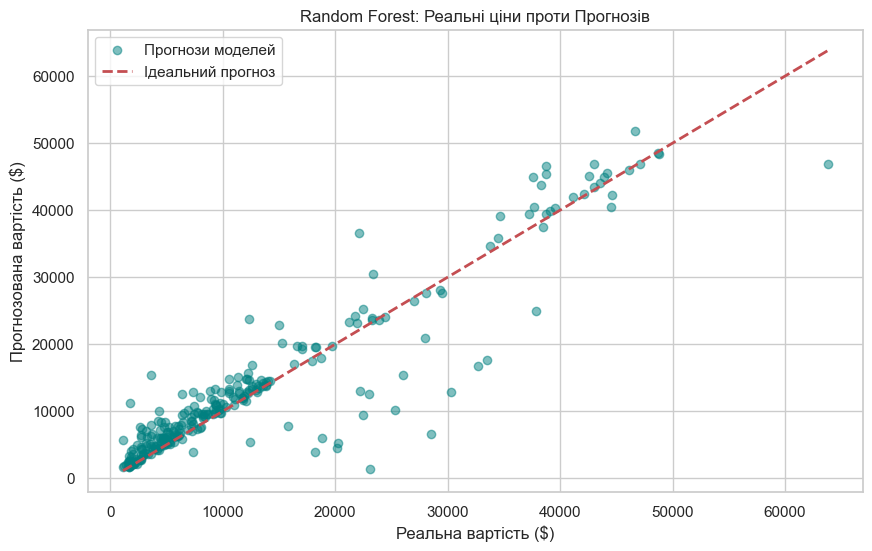

In [9]:

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal', label='Прогнози моделей')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ідеальний прогноз')

plt.xlabel('Реальна вартість ($)')
plt.ylabel('Прогнозована вартість ($)')
plt.title('Random Forest: Реальні ціни проти Прогнозів')
plt.legend()
plt.show()

In [ ]:
Random Forest (Горизонтальні стовпчики)

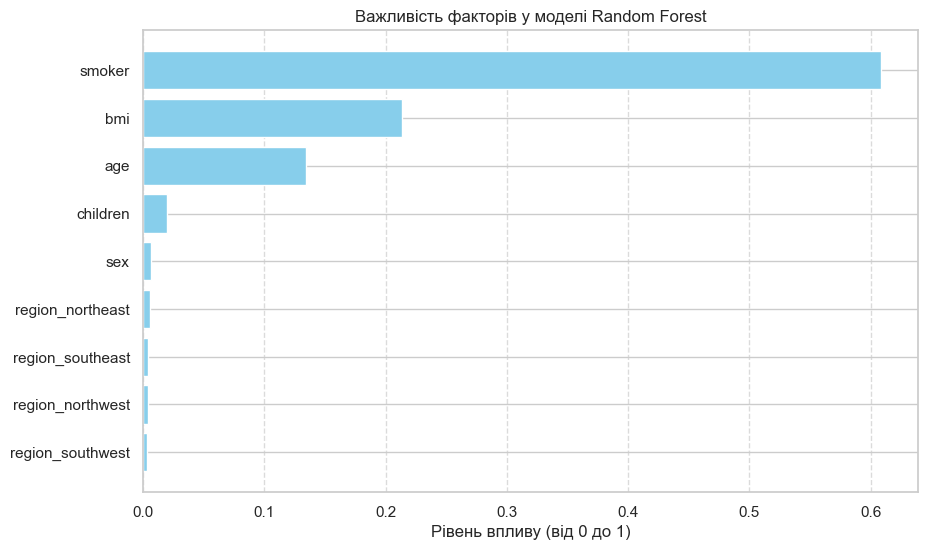

In [10]:

importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Ознака': feature_names, 'Важливість': importances})


feature_importance_df = feature_importance_df.sort_values(by='Важливість', ascending=True)

а
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Ознака'], feature_importance_df['Важливість'], color='skyblue')
plt.title('Важливість факторів у моделі Random Forest')
plt.xlabel('Рівень впливу (від 0 до 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Висновок:
Random Forest виявився набагато точнішим за звичайну регресію. Його показник R2 становить приблизно 0.86, що є дуже гарним  результатом. Лінійна регресія видала лише 0.78 — це тому, що в даних є складні зв'язки, які вона не може вловити (наприклад, коли паління сильно б'є по кишені саме людей з великою вагою).
Головні чинники впливу:
Найбільше на ціну впливає те, чи курить людина — у курців страховка дорожча у 3-4 рази. Також важливими є вік та індекс маси тіла (BMI) — чим вони більші, тим дорожче поліс. А от стать чи регіон проживання майже не мають значення для фінальної вартості.

Одже, ця модель можна реально використовувати для того, щоб автоматично рахувати ціну страховки. Вона працює швидко і дуже точно вгадує суму на основі здоров'я та способу життя клієнта.